

```
Name : Supriya MS
# QuickCart Warehouse Inventory — Stockout Risk Classification

**Goal:** For every (store, SKU, day), predict whether inventory is **Safe**, **At-Risk**, or **Imminent** (about to stock out before the next supplier delivery).

This is a multi-table, imbalanced, 3-class classification project. The notebook is organized as:

1. Setup & data loading
2. Sanity checks (verify against the locked numbers in the spec)
3. Data-quality fixes (the two planted gotchas)
4. Joining the tables into one modeling table
5. Exploratory data analysis (the "money-moment" signals)
6. Feature engineering
7. Train/test split (time-based, to avoid leakage)
8. Modeling: baseline → logistic regression → random forest / gradient boosting
9. Evaluation (with emphasis on **recall for the Imminent class**)
10. Feature importance & takeaways

```



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4)

RANDOM_STATE = 42


In [7]:
na_markers = ["N/A", "NA", "na", "missing", "--", "null", "None", ""]

dim_stores = pd.read_csv("dim_stores.csv", na_values=na_markers, keep_default_na=True)
dim_skus = pd.read_csv("dim_skus.csv", na_values=na_markers, keep_default_na=True)
dim_suppliers = pd.read_csv("dim_suppliers.csv", na_values=na_markers, keep_default_na=True)
dim_events = pd.read_csv("dim_events.csv", na_values=na_markers, keep_default_na=True, parse_dates=["date"])
fact = pd.read_csv("fact_inventory_daily.csv", na_values=na_markers, keep_default_na=True, parse_dates=["date"])

print(dim_stores.shape, dim_skus.shape, dim_suppliers.shape, dim_events.shape, fact.shape)

(12, 8) (60, 9) (15, 6) (30, 5) (21600, 16)


## 2. Sanity Checks

The spec ships "locked" numbers. If these don't match, something broke in the load or join — check before doing any modeling.


In [8]:
assert dim_stores.shape[0] == 12, "Expected 12 stores"
assert dim_skus.shape[0] == 60, "Expected 60 SKUs"
assert dim_suppliers.shape[0] == 15, "Expected 15 suppliers"
assert dim_events.shape[0] == 30, "Expected 30 calendar days"
assert fact.shape[0] == 21600, "Expected 21,600 fact rows (12 stores x 60 SKUs x 30 days)"

print("Row counts all match the spec.")

target_dist = fact["stockout_risk"].value_counts(normalize=True).mul(100).round(2)
print(target_dist)

Row counts all match the spec.
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


In [9]:
print("Date range:", fact["date"].min().date(), "to", fact["date"].max().date())
print("Unique dates:", fact["date"].nunique())
assert fact["date"].nunique() == 30


Date range: 2026-10-01 to 2026-10-30
Unique dates: 30


In [10]:
diwali = dim_events[dim_events["event_name"].str.contains("Diwali", case=False, na=False)]
print("Diwali Week rows in dim_events:")
print(diwali[["date", "event_name", "demand_multiplier_festive"]])

peak_row = dim_events.loc[dim_events["demand_multiplier_festive"].idxmax()]
print(f"\nPeak festive multiplier: {peak_row['demand_multiplier_festive']}x on {peak_row['date'].date()}")
assert peak_row["date"] == pd.Timestamp("2026-10-25") and peak_row["demand_multiplier_festive"] == 2.6, \
    "Expected Diwali peak of 2.6x on Oct 25"

flash_sale = dim_events[dim_events["event_name"] == "Weekend Flash Sale"]
print("\nWeekend Flash Sale row:")
print(flash_sale[["date", "event_name", "demand_multiplier_festive", "demand_multiplier_other"]])
assert (flash_sale["date"].iloc[0] == pd.Timestamp("2026-10-11")
        and flash_sale["demand_multiplier_festive"].iloc[0] == 1.3
        and flash_sale["demand_multiplier_other"].iloc[0] == 1.3), \
    "Expected Weekend Flash Sale on Oct 11 at 1.3x for all categories"


Diwali Week rows in dim_events:
         date   event_name  demand_multiplier_festive
21 2026-10-22  Diwali Week                        1.4
22 2026-10-23  Diwali Week                        1.7
23 2026-10-24  Diwali Week                        2.1
24 2026-10-25  Diwali Week                        2.6
25 2026-10-26  Diwali Week                        1.9

Peak festive multiplier: 2.6x on 2026-10-25

Weekend Flash Sale row:
         date          event_name  demand_multiplier_festive  \
10 2026-10-11  Weekend Flash Sale                        1.3   

    demand_multiplier_other  
10                      1.3  


In [11]:
missing_lead_actual = fact["lead_time_days_actual"].isna().sum()
print(f"Missing lead_time_days_actual: {missing_lead_actual} of {len(fact)} "
      f"({missing_lead_actual/len(fact):.1%})")

Missing lead_time_days_actual: 19899 of 21600 (92.1%)


## 3. Planted Data-Quality Issues

### 3a. Inconsistent city casing (`dim_stores.csv`)

`city` is the clean join key. `city_display` is a display-only field, and 2 of the 12 rows
have casing that doesn't match `city` (one upper-cased, one lower-cased). Grouping on
`city_display` directly would silently create duplicate "cities". Fix with `.str.title()`.

In [12]:
mismatch = dim_stores[dim_stores["city"] != dim_stores["city_display"]]
print("Rows where city_display doesn't match city:")
print(mismatch[["store_id", "city", "city_display"]])

# Demonstrate the bug: naive groupby on the dirty column over-counts categories
print("\nUnique values if you naively group by city_display:", dim_stores["city_display"].nunique())
print("Unique values after standardizing:", dim_stores["city_display"].str.title().nunique())

# Fix: use the clean `city` key from here on, or standardize city_display
dim_stores["city_display_clean"] = dim_stores["city_display"].str.title()

Rows where city_display doesn't match city:
  store_id       city city_display
2     ST03  Bengaluru    BENGALURU
8     ST09  Hyderabad    hyderabad

Unique values if you naively group by city_display: 8
Unique values after standardizing: 6


### 3b. The `'N/A'` reliability score (`dim_suppliers.csv`)

3 of 15 suppliers stored `reliability_score` as the literal string `'N/A'`. Because we passed
an explicit `na_values` list at load time above, these are already proper `NaN` — but it's
worth seeing what would have happened by default, and how we fix it (impute with the category
median rather than leaving it as NaN or silently as a string).


In [13]:
n_missing_reliability = dim_suppliers["reliability_score"].isna().sum()
print(f"Suppliers with missing reliability_score: {n_missing_reliability} (expected: 3)")
print(dim_suppliers[dim_suppliers["reliability_score"].isna()][["supplier_id", "supplier_name", "reliability_score"]])


Suppliers with missing reliability_score: 3 (expected: 3)
   supplier_id          supplier_name  reliability_score
5        SUP06  QuickBev Distributors                NaN
13       SUP14    Prime Personal Care                NaN
14       SUP15   Regional Produce Hub                NaN


In [14]:
raw_suppliers = pd.read_csv("dim_suppliers.csv", keep_default_na=False)
print("Raw (unparsed) reliability_score values:")
print(raw_suppliers["reliability_score"].tolist())

Raw (unparsed) reliability_score values:
['0.92', '0.93', '0.9', '0.7', '0.66', 'N/A', '0.67', '0.73', '0.72', '0.66', '0.83', '0.63', '0.91', 'N/A', 'N/A']


In [15]:
median_reliability = dim_suppliers["reliability_score"].median()
dim_suppliers["reliability_score_clean"] = dim_suppliers["reliability_score"].fillna(median_reliability)

print(f"Median reliability used for imputation: {median_reliability:.3f}")
dim_suppliers[["supplier_id", "reliability_score", "reliability_score_clean"]]

Median reliability used for imputation: 0.725


,supplier_id,reliability_score,reliability_score_clean
0,SUP01,0.92,0.920
1,SUP02,0.93,0.930
2,SUP03,0.90,0.900
3,SUP04,0.70,0.700
4,SUP05,0.66,0.660
5,SUP06,NaN,0.725
6,SUP07,0.67,0.670
7,SUP08,0.73,0.730
8,SUP09,0.72,0.720
9,SUP10,0.66,0.660


## 4. Joining the Tables

`fact_inventory_daily` is the grain table (store x SKU x day). We join in store, SKU, supplier,
and calendar-event attributes to build one flat modeling table.


In [16]:
df = fact.merge(dim_stores[["store_id", "city", "city_tier", "store_size", "sqft",
                             "opened_year", "baseline_daily_orders"]],
                 on="store_id", how="left")

df = df.merge(dim_skus[["sku_id", "sku_name", "category", "unit_price_inr", "shelf_life_days",
                         "is_perishable", "festive_relevant", "popularity_tier"]],
              on="sku_id", how="left", suffixes=("", "_sku"))

df = df.merge(dim_suppliers[["supplier_id", "supplier_name", "reliability_score_clean",
                              "base_lead_time_days", "lead_time_variance_days"]],
              on="supplier_id", how="left")

df = df.merge(dim_events[["date", "event_name", "event_type",
                           "demand_multiplier_festive", "demand_multiplier_other"]],
              on="date", how="left")

assert len(df) == 21600, "Row count changed after joins -- check for fan-out or key mismatch"
print(df.shape)
df.head()


(21600, 37)


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk,city,city_tier,store_size,sqft,opened_year,baseline_daily_orders,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_name,reliability_score_clean,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,1,NaN,12.50,8.79,N,Safe,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,1,NaN,11.80,8.55,N,Safe,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,0.83,1,2.5,Regular Day,none,1.0,1.0


## 5. Exploratory Data Analysis — the "Money-Moment" Signals

The spec calls out three effects worth verifying before modeling: festival timing, supplier
reliability, and perishability. These become natural, high-value features.


In [17]:
imminent = (df["stockout_risk"] == "Imminent")

rate_festival = imminent[df["is_festival_week"] == "Y"].mean() * 100
rate_non_festival = imminent[df["is_festival_week"] == "N"].mean() * 100

print(f"Imminent rate, non-festival days: {rate_non_festival:.2f}%  (expected ~9.51%)")
print(f"Imminent rate, festival week:     {rate_festival:.2f}%  (expected ~23.31%)")
print(f"Spike factor: {rate_festival/rate_non_festival:.2f}x  (expected ~2.45x)")


Imminent rate, non-festival days: 9.51%  (expected ~9.51%)
Imminent rate, festival week:     23.31%  (expected ~23.31%)
Spike factor: 2.45x  (expected ~2.45x)


In [18]:
raw_reliability = df[["supplier_id"]].merge(
    dim_suppliers[["supplier_id", "reliability_score"]], on="supplier_id", how="left"
)["reliability_score"]

bins = pd.cut(raw_reliability, bins=[0, 0.75, 0.85, 1.0],
              labels=["low (<0.75)", "mid (0.75-0.85)", "high (>=0.85)"])
reliability_effect = imminent.groupby(bins, observed=True).mean().mul(100).round(2)
print("Imminent rate by supplier reliability tier (raw score, pre-imputation):")
print(reliability_effect)

Imminent rate by supplier reliability tier (raw score, pre-imputation):
reliability_score
low (<0.75)        15.83
mid (0.75-0.85)     3.26
high (>=0.85)       3.82
Name: stockout_risk, dtype: float64


In [19]:
perishable_effect = imminent.groupby(df["is_perishable"]).mean().mul(100).round(2)
print("Imminent rate by perishability:")
print(perishable_effect)

Imminent rate by perishability:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64


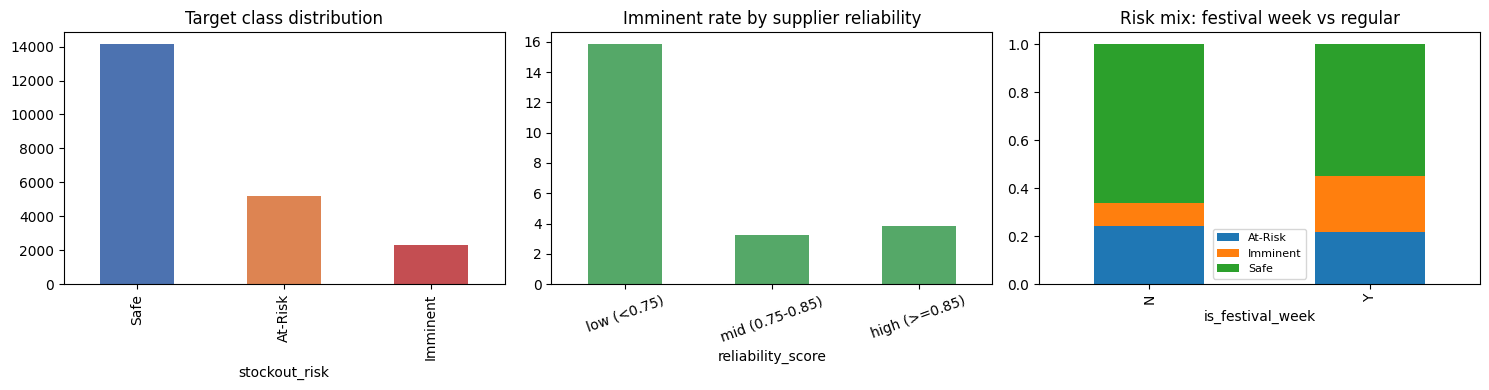

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["stockout_risk"].value_counts().reindex(["Safe", "At-Risk", "Imminent"]).plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#dd8452", "#c44e52"])
axes[0].set_title("Target class distribution")

reliability_effect.plot(kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("Imminent rate by supplier reliability")
axes[1].tick_params(axis="x", rotation=20)

df.groupby("is_festival_week")["stockout_risk"].value_counts(normalize=True).unstack().loc[["N", "Y"]].plot(
    kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("Risk mix: festival week vs regular")
axes[2].legend(title="", fontsize=8)

plt.tight_layout()
plt.show()


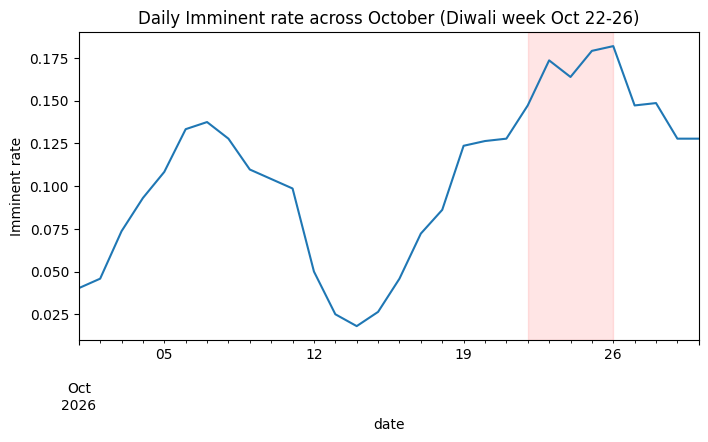

In [21]:
daily_imminent_rate = df.groupby("date").apply(lambda g: (g["stockout_risk"] == "Imminent").mean(),
                                                include_groups=False)
daily_imminent_rate.plot(title="Daily Imminent rate across October (Diwali week Oct 22-26)")
plt.axvspan(pd.Timestamp("2026-10-22"), pd.Timestamp("2026-10-26"), color="red", alpha=0.1)
plt.ylabel("Imminent rate")
plt.show()


## 6. Feature Engineering

The raw fact table is deliberately not model-ready. We build the features suggested in the spec:

- `reorder_gap` — distance from the reorder trigger point
- `days_of_cover_ratio` — days of cover normalized by expected lead time
- `is_recent_reorder` — whether a reorder was placed in the last N days (per store-SKU, needs a shift)
- one-hot encoded `category`
- temporal features around the Diwali spike
- cleaned/encoded categorical and boolean flags


In [22]:
df = df.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)

# reorder_gap: how far past/before the reorder trigger point
df["reorder_gap"] = df["reorder_point"] - df["closing_stock"]

# days_of_cover_ratio: normalize cover by the expected supplier lead time
df["days_of_cover_ratio"] = df["days_of_cover"] / df["lead_time_days_expected"].replace(0, np.nan)

# is_recent_reorder: was a reorder placed in the last 3 days for this store-SKU pair?
df["reorder_placed_flag"] = (df["reorder_placed"] == "Y").astype(int)
df["is_recent_reorder"] = (
    df.groupby(["store_id", "sku_id"])["reorder_placed_flag"]
      .transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
      .fillna(0)
      .astype(int)
)

# temporal features around the Diwali spike (Oct 22-26)
df["day_of_month"] = df["date"].dt.day
diwali_start = pd.Timestamp("2026-10-22")
df["days_since_festival_start"] = (df["date"] - diwali_start).dt.days.clip(lower=0)

# binary flags -> 0/1
for col in ["is_perishable", "festive_relevant"]:
    df[col + "_flag"] = (df[col] == "Y").astype(int)
df["is_festival_week_flag"] = (df["is_festival_week"] == "Y").astype(int)

# demand multiplier actually applicable to this SKU (festive multiplier if festive_relevant, else 'other')
df["applicable_demand_multiplier"] = np.where(
    df["festive_relevant_flag"] == 1, df["demand_multiplier_festive"], df["demand_multiplier_other"]
)

df[["reorder_gap", "days_of_cover_ratio", "is_recent_reorder",
    "day_of_month", "days_since_festival_start", "applicable_demand_multiplier"]].describe()


,reorder_gap,days_of_cover_ratio,is_recent_reorder,day_of_month,days_since_festival_start,applicable_demand_multiplier
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000
mean,-53.536347,4.696304,0.220694,15.500000,1.200000,1.094208
std,104.712819,4.491873,0.414724,8.655642,2.315221,0.260144
min,-810.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,-78.500000,1.628000,0.000000,8.000000,0.000000,1.000000
50%,-26.300000,3.143333,0.000000,15.500000,0.000000,1.000000
75%,0.000000,6.480000,0.000000,23.000000,1.000000,1.000000
max,393.500000,134.850000,1.000000,30.000000,8.000000,2.600000


## 7. Train / Test Split (Time-Based)

This is a daily panel: the same store-SKU pairs repeat across 30 days. A random row-level split
leaks information (the model could "memorize" a pair's pattern from training days and just
interpolate for test days of the *same* pair). We use a **time-based split** instead: train on
Oct 1–23, test on Oct 24–30 — which conveniently includes the back half of Diwali week, a
genuinely hard generalization test.


In [23]:
feature_cols = [
    "opening_stock", "units_demanded", "units_sold", "closing_stock",
    "reorder_point", "reorder_placed_flag", "lead_time_days_expected",
    "sales_velocity_7d", "days_of_cover", "reorder_gap", "days_of_cover_ratio",
    "is_recent_reorder", "day_of_month", "days_since_festival_start",
    "applicable_demand_multiplier", "is_perishable_flag", "festive_relevant_flag",
    "is_festival_week_flag", "reliability_score_clean", "base_lead_time_days",
    "lead_time_variance_days", "unit_price_inr", "shelf_life_days",
    "sqft", "baseline_daily_orders",
] + [c for c in df.columns if c.startswith(("cat_", "pop_", "size_", "evt_"))]

target_col = "stockout_risk"

train_mask = df["date"] <= "2026-10-23"
test_mask = df["date"] > "2026-10-23"

X_train, y_train = df.loc[train_mask, feature_cols], df.loc[train_mask, target_col]
X_test, y_test = df.loc[test_mask, feature_cols], df.loc[test_mask, target_col]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train: (16560, 25)  Test: (5040, 25)
Train class balance:
 stockout_risk
Safe        0.664
At-Risk     0.245
Imminent    0.091
Name: proportion, dtype: float64
Test class balance:
 stockout_risk
Safe        0.623
At-Risk     0.223
Imminent    0.154
Name: proportion, dtype: float64


In [24]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

Series([], dtype: int64)


## 8. Modeling

**Metric focus:** recall on the **Imminent** class matters most — missing a real stockout
(false negative) is far costlier than a false alarm. We report full classification reports but
call out Imminent recall specifically for every model.

### 8a. Baseline — majority-class classifier


In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)

print("Baseline (majority class) performance:")
print(classification_report(y_test, baseline_preds, zero_division=0))


Baseline (majority class) performance:
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



### 8b. Multinomial Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

print("Logistic Regression performance:")
print(classification_report(y_test, logreg_preds, zero_division=0))


Logistic Regression performance:
              precision    recall  f1-score   support

     At-Risk       0.95      0.62      0.75      1126
    Imminent       0.70      0.97      0.81       775
        Safe       0.97      0.99      0.98      3139

    accuracy                           0.91      5040
   macro avg       0.87      0.86      0.85      5040
weighted avg       0.92      0.91      0.90      5040



In [27]:
coefs = pd.DataFrame(
    logreg.named_steps["clf"].coef_,
    columns=feature_cols,
    index=logreg.named_steps["clf"].classes_,
).T
coefs["abs_mean"] = coefs.abs().mean(axis=1)
coefs.sort_values("abs_mean", ascending=False).head(15)


,At-Risk,Imminent,Safe,abs_mean
days_of_cover,-3.930638,-7.164442,11.095080,7.396720
days_of_cover_ratio,1.118703,-6.615493,5.496791,4.410329
reorder_gap,1.206669,0.402442,-1.609110,1.072740
units_demanded,-1.399091,1.490122,-0.091030,0.993414
units_sold,1.409315,-1.385550,-0.023765,0.939543
lead_time_days_expected,0.532143,0.669916,-1.202059,0.801373
base_lead_time_days,0.532143,0.669916,-1.202059,0.801373
sales_velocity_7d,0.178794,1.008961,-1.187754,0.791836
opening_stock,-0.139314,-0.863870,1.003184,0.668790
closing_stock,-0.627339,-0.370314,0.997654,0.665102


8b. Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest performance:")
print(classification_report(y_test, rf_preds, zero_division=0))


Random Forest performance:
              precision    recall  f1-score   support

     At-Risk       0.87      0.90      0.89      1126
    Imminent       0.85      0.82      0.83       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.95      5040
   macro avg       0.91      0.91      0.91      5040
weighted avg       0.95      0.95      0.95      5040



### 8d. Gradient Boosting

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

print("Gradient Boosting performance:")
print(classification_report(y_test, gb_preds, zero_division=0))


Gradient Boosting performance:
              precision    recall  f1-score   support

     At-Risk       0.88      0.94      0.91      1126
    Imminent       0.91      0.82      0.86       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.96      5040
   macro avg       0.93      0.92      0.92      5040
weighted avg       0.96      0.96      0.96      5040



## 9. Model Comparison — Focus on Imminent Recall


In [30]:
models = {
    "Baseline (majority class)": baseline_preds,
    "Logistic Regression": logreg_preds,
    "Random Forest": rf_preds,
    "Gradient Boosting": gb_preds,
}

summary = []
for name, preds in models.items():
    imminent_recall = recall_score(y_test, preds, labels=["Imminent"], average="macro", zero_division=0)
    macro_recall = recall_score(y_test, preds, average="macro", zero_division=0)
    summary.append({"model": name, "imminent_recall": round(imminent_recall, 3),
                     "macro_recall": round(macro_recall, 3)})

summary_df = pd.DataFrame(summary).sort_values("imminent_recall", ascending=False)
summary_df


,model,imminent_recall,macro_recall
1,Logistic Regression,0.974,0.863
3,Gradient Boosting,0.825,0.921
2,Random Forest,0.819,0.906
0,Baseline (majority class),0.000,0.333


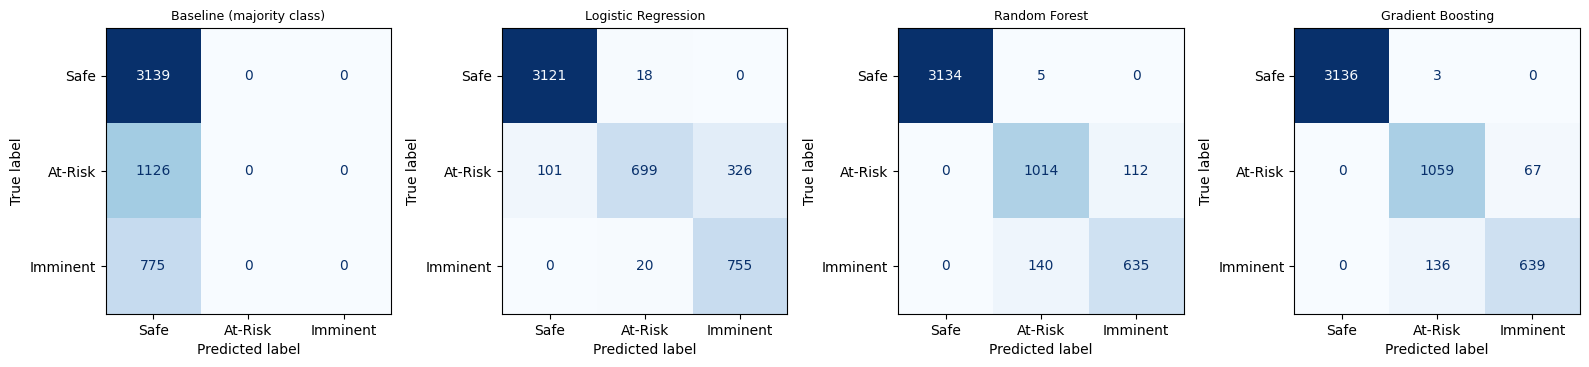

In [31]:
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4))
labels_order = ["Safe", "At-Risk", "Imminent"]

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()


## 10. Feature Importance & Takeaways


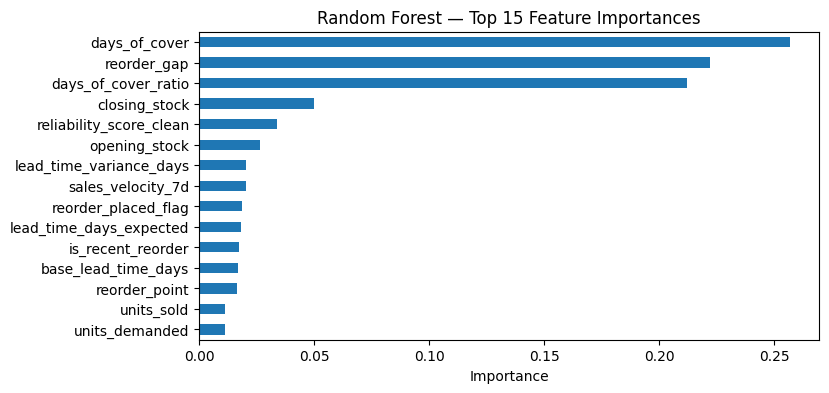

,0
days_of_cover,0.256823
reorder_gap,0.222044
days_of_cover_ratio,0.212330
closing_stock,0.050074
reliability_score_clean,0.034027
opening_stock,0.026476
lead_time_variance_days,0.020545
sales_velocity_7d,0.020192
reorder_placed_flag,0.018681
lead_time_days_expected,0.018315


In [32]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

importances.head(15)
